Benchmark for the blood atlas dataset (with all major cell types). The dataset is downloaded from https://explore.data.humancellatlas.org/projects/896f377c-8e88-463e-82b0-b2a5409d6fe4/project-matrices (all_pbmcs.tar.gz), then processed in `blood_atlas_data_preparation.ipynb`. The processed dataset is then read in in this notebook, and benchmarked.

In [1]:
import sys
from pathlib import Path
import os
import scanpy as sc
import numpy as np

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

In [2]:
from scrna_benchmark.embedding import (
    compute_hvg_subset,
    compute_pca,
    compute_harmony,
)

adata_path = "data/blood_atlas/blood_atlas_subsampled.h5ad"
out_path = "data/blood_atlas/blood_atlas_benchmark_ready.h5ad"

adata = sc.read_h5ad(adata_path)

print(adata)
print(adata.obs[["donor_id", "cell_type", "batch", "sample_id"]].head())
print("n donors:", adata.obs["donor_id"].nunique())
print("n cell types:", adata.obs["cell_type"].nunique())
print("n batches:", adata.obs["batch"].nunique())

AnnData object with n_obs × n_vars = 108682 × 36601
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'percent.mt', 'percent.ribo', 'log2_nCount', 'log2_nFeature', 'log2_mt', 'Donor_id', 'Age_group', 'Sex', 'Age', 'Tube_id', 'Batch', 'File_name', 'Cluster_names', 'Cluster_numbers', 'donor_id', 'cell_type', 'batch', 'sample_id', 'age', 'age_group', 'sex'
                                donor_id      cell_type  batch     sample_id
ALAW-AS061-8_TCAATCTTCTCTGTCG-1      A30       NK cells  AS061  ALAW-AS061-2
ALAW-AS060-3_CGCCAAGCAATGCCAT-1      A15        B cells  AS056  ALAW-AS056-2
ALAW-AS052-3_GGGTCTGAGACTCGGA-1      A22  Myeloid cells  AS058  ALAW-AS058-1
ALAW-AS056-7_GTACTTTCAAGGTGTG-1      A35   CD4+ T cells  AS061  ALAW-AS061-3
ALAW-AS058-2_TGGCCAGCAGCCAATT-1      B12     gd T cells  AS055  ALAW-AS055-1
n donors: 166
n cell types: 7
n batches: 14


In [3]:
adata.raw = adata.copy()

adata = compute_hvg_subset(
    adata,
    n_top_genes=1000,
    batch_key="donor_id",
)

adata = compute_pca(
    adata,
    n_comps=20,
    key_added="X_pca",
    random_state=42,
)

adata = compute_harmony(
    adata,
    batch_col="donor_id",
    basis="X_pca",
    key_added="X_harmony",
)

print("Final benchmark-ready object:")
print(adata)
print("obsm keys:", list(adata.obsm.keys()))

adata.write_h5ad(
    "data/blood_atlas/blood_atlas_benchmark_ready.h5ad",
    compression="gzip",
)

2026-05-25 16:55:56,904 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-25 16:55:56,905 - harmonypy - INFO -   Parameters:
2026-05-25 16:55:56,906 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-25 16:55:56,907 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-25 16:55:56,908 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-25 16:55:56,909 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-25 16:55:56,910 - harmonypy - INFO -     nclust: 100
2026-05-25 16:55:56,911 - harmonypy - INFO -     block_size: 0.05
2026-05-25 16:55:56,914 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

Final benchmark-ready object:
AnnData object with n_obs × n_vars = 108682 × 1000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'percent.mt', 'percent.ribo', 'log2_nCount', 'log2_nFeature', 'log2_mt', 'Donor_id', 'Age_group', 'Sex', 'Age', 'Tube_id', 'Batch', 'File_name', 'Cluster_names', 'Cluster_numbers', 'donor_id', 'cell_type', 'batch', 'sample_id', 'age', 'age_group', 'sex'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca'
    obsm: 'X_pca', 'X_harmony'
    varm: 'PCs'
obsm keys: ['X_pca', 'X_harmony']


In [4]:
from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

adata_path = "data/blood_atlas/blood_atlas_benchmark_ready.h5ad"

common_representations = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
}

config_no_batch = DatasetConfig(
    dataset_name="blood_atlas_no_batch",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="donor_id",
    batch_col=None,
    group_col="batch",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    # keep off first
    run_group_transfer=False,

    run_donor_ablation=True,
    donor_ablation_k_values=[5, 10, 20, 40, 80, 120],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=True,
    verbose=True,
)

outputs_no_batch = run_dataset_benchmark(config_no_batch)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)

Running donor ablation for hvg (hvg)
  k= 5, repeat=1: macro_f1=0.2349, acc=0.2316
  k= 5, repeat=2: macro_f1=0.2628, acc=0.2866
  k= 5, repeat=3: macro_f1=0.2190, acc=0.2119
  k= 5, repeat=4: macro_f1=0.2591, acc=0.2803
  k= 5, repeat=5: macro_f1=0.2267, acc=0.2251
  k=10, repeat=1: macro_f1=0.2417, acc=0.2427
  k=10, repeat=2: macro_f1=0.2275, acc=0.2296
  k=

In [ ]:
config_with_batch = DatasetConfig(
    dataset_name="blood_atlas_with_batch_covariate",
    adata_path=adata_path,
    output_dir="results",

    celltype_col="cell_type",
    donor_col="donor_id",
    batch_col="batch",
    group_col="batch",

    representations=common_representations,

    min_cells=200,
    min_donors=5,

    run_random_split=True,
    run_donor_cv=True,

    # keep these off for covariate sensitivity
    run_group_transfer=False,
    run_donor_ablation=False,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_with_batch = run_dataset_benchmark(config_with_batch)

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dir = Path("results/blood_atlas_no_batch")
batch_result_dir = Path("results/blood_atlas_with_batch_covariate")
figures_dir = result_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

rep_order = ["hvg", "pca", "harmony"]
rep_labels = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
}

def clean_rep(x):
    return {
        "hvg": "hvg",
        "pca": "pca",
        "harmony": "harmony",
        "X_pca": "pca",
        "X_harmony": "harmony",
        "X_pca_harmony": "harmony",
    }.get(x, x)

def summarize_repeated(df):
    return (
        df.groupby("rep_clean", as_index=False)
        .agg(
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
        )
    )

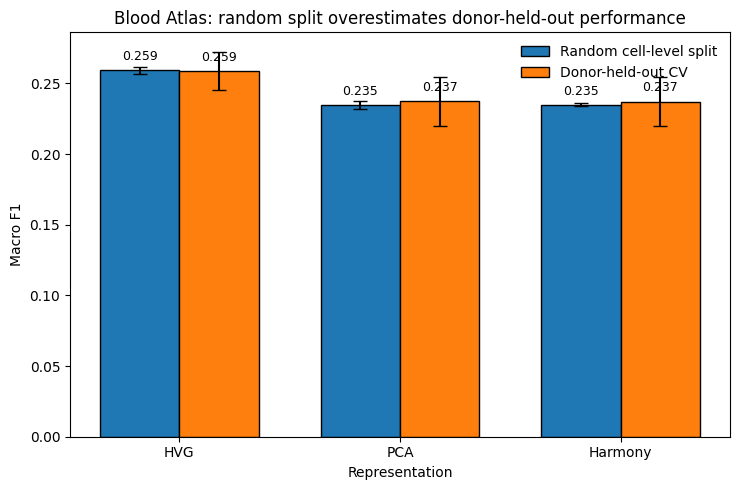

Saved: results/blood_atlas_no_batch/figures/blood_atlas_random_vs_donor_cv.png


In [6]:
random_df = pd.read_csv(result_dir / "random_split" / "random_split_repeated_metrics.csv")
donor_df = pd.read_csv(result_dir / "donor_cv" / "metrics.csv")

random_df["rep_clean"] = random_df["representation"].map(clean_rep)
donor_df["rep_clean"] = donor_df["representation"].map(clean_rep)

random_summary = summarize_repeated(random_df)

common_reps = [
    r for r in rep_order
    if r in set(random_summary["rep_clean"]) and r in set(donor_df["rep_clean"])
]

random_plot = random_summary.set_index("rep_clean").loc[common_reps]
donor_plot = donor_df.set_index("rep_clean").loc[common_reps]

x = np.arange(len(common_reps))
width = 0.36

fig, ax = plt.subplots(figsize=(7.5, 5))

bars_random = ax.bar(
    x - width / 2,
    random_plot["macro_f1_mean"],
    width,
    yerr=random_plot["macro_f1_std"],
    capsize=5,
    label="Random cell-level split",
    edgecolor="black",
)

bars_donor = ax.bar(
    x + width / 2,
    donor_plot["macro_f1_mean"],
    width,
    yerr=donor_plot["macro_f1_std"],
    capsize=5,
    label="Donor-held-out CV",
    edgecolor="black",
)

ax.set_xticks(x)
ax.set_xticklabels([rep_labels[r] for r in common_reps])
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Blood Atlas: random split overestimates donor-held-out performance")
ax.legend(frameon=False)

for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
out_png = figures_dir / "blood_atlas_random_vs_donor_cv.png"
# plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png)